# Epistemic Foraging with Competing Drives


## Scenario

This experiment builds on Experiment 1 by combining it with the [T-maze](https://pymdp-rtd.readthedocs.io/en/latest/notebooks/tmaze_demo.html) example found in the pymdp repo.

Similarly to Experiment 1, we have two goal types (Food and Shelter) which provide relief from competing drives (Hunger and Stress).

This time however, each goal's true location could be in one of two places with 50% probability.

There is a 'cue' square in the corners furthest away from the potential goals. Moving towards it is a move away from the goal.

The agent is confident that if it lands on it the resulting observation will remove all uncertainty about the world state.

It will get clear information about both goal locations and so know with 100% probability which to pick.

This is achieved by having two new hidden states (true location of each goal).

They each have two possible values (Location 1 or 2).

If the agent is at any other square than the cue, it observes Null which doesn't provide any information.

If it is on the cue square, its observation includes the true locations, so it updates its state prediction to reflect that.

In [46]:
%pip install inferactively-pymdp

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
import numpy as np
from pymdp.agent import Agent
from pymdp import utils

## Hidden States

We will use a 3*3 grid here because it's enough to show the desired behaviour.

In [48]:
grid_dims = [3, 3]
n_grid_points = int(np.prod(grid_dims))
shelter_locs = [(1, 0), (2, 0)]
food_locs = [(1, 2), (2, 2)]
cue_loc = (0, 2)
max_drive = 10

print(f"Grid dimensions: {grid_dims}")
print(f"Potential food locations: {food_locs}")
print(f"Potential shelter locations: {shelter_locs}")
print(f"Cue location: {cue_loc}")
print(f"Maximum drive level: {max_drive}")

Grid dimensions: [3, 3]
Potential food locations: [(1, 2), (2, 2)]
Potential shelter locations: [(1, 0), (2, 0)]
Cue location: (0, 2)
Maximum drive level: 10


In [49]:
# Create a look-up table `loc_list` that maps linear indices to (y, x) coordinates
grid = np.arange(n_grid_points).reshape(grid_dims)
loc_list = []
for y in range(grid_dims[0]):
    for x in range(grid_dims[1]):
        loc_list.append((y, x))

In [50]:
hunger_levels = np.arange(max_drive + 1)  # 0 to max_drive, inclusive
stress_levels = np.arange(max_drive + 1) 
n_hunger = len(hunger_levels)
n_stress = len(stress_levels)

n_states = [
    n_grid_points,
    n_hunger,
    n_stress,
    2, # Food Context (2 possible locations)
    2  # Shelter Context (2 possible locations)
]

n_obs = [
    n_grid_points,
    n_hunger,
    n_stress,
    3, # Food Cue observation (Null, Hint0, Hint1)
    3  # Shelter Cue observation (Null, Hint0, Hint1)
]

## A Matrix: Observation -> State

The A matrix is similar to the previous experiments in that location, hunger and stress are perfect observation, identity matrices.

This time we have also have the Food and Shelter Context hidden states, so the A matrix encodes that
- If you aren't on Cue, expect to observe Null which provides no information about the contexts.
- If you are on Cue, expect to observe confident context predictions.

In effect, visiting the Cue reveals the true state of the world which is otherwise masked.

In [51]:
A = utils.obj_array_zeros([[n] + n_states for n in n_obs])

# Fill A
for loc_idx in range(n_grid_points):
    loc_yx = loc_list[loc_idx]
    
    for h in range(n_hunger):
        for s in range(n_stress):
            for f_ctx in range(2):
                for s_ctx in range(2):
                    A[0][loc_idx, loc_idx, h, s, f_ctx, s_ctx] = 1.0
                    A[1][h, loc_idx, h, s, f_ctx, s_ctx] = 1.0
                    A[2][s, loc_idx, h, s, f_ctx, s_ctx] = 1.0

                    # Check if at a cue (reveals both contexts)
                    at_cue = (loc_yx == cue_loc)
                    # Check if at a food candidate (reveals food context)
                    at_food_candidate = (loc_yx in food_locs)
                    # Check if at a shelter candidate (reveals shelter context)
                    at_shelter_candidate = (loc_yx in shelter_locs)
                    
                    # Food Cue observation
                    if at_cue or at_food_candidate:
                        A[3][f_ctx + 1, loc_idx, h, s, f_ctx, s_ctx] = 1.0 # Reveal
                    else:
                        A[3][0, loc_idx, h, s, f_ctx, s_ctx] = 1.0  # Null
                    
                    # Shelter Cue observation
                    if at_cue or at_shelter_candidate:
                        A[4][s_ctx + 1, loc_idx, h, s, f_ctx, s_ctx] = 1.0 # Reveal
                    else:
                        A[4][0, loc_idx, h, s, f_ctx, s_ctx] = 1.0  # Null

## B Matrix: State -> Action -> State

The B matrix is similar to previous experiments, but this time has encoded that

- There's a 1:1 correlation between the goal contexts (0 or 1) and which goals lead to relief from hunger / stress. This implies that the more confidently you know the contexts, the more confident you are of the locations that successful policies will visit.

- Moving into a state where the location is not the true location but *is* in the candidate list (i.e. is the wrong choice) *will* transition to *maximum* hunger / stress on the next timestep. This adds an incentive to avoid gambling as there is an actual penalty, dissuading an agent from travelling through both candidates if it was a shorter path than info. 

- Your hunger state tansition from t to t+1 is a function of
1.) Your current hunger
2.) Your location
3.) The relevant goal context (new)

- If not a candidate, current_value + 1
- If true goal, = 0
- If candidate but not true goal, = max_drive

### Agent perspective
- 'If I land on the real food pile at time t, I will transition to minimum hunger at t+1.'
- 'If I land on the fake food pile at time t, I will transition to max hunger at t+1.'
- 'If I land on any square that isn't the food pile at time t, I will get an (increasingly disliked) hunger increment of +1 at t+1.'
- 'At the start, landing on a candidate square may reset *or* max out my hunger depending upon goal context which we are ambiguous about. Any policy that passes through a candidate has equal chance of relief or catastrophe, so I can't confidently score it.'
- 'If I land on the cue square, I observe the contexts for certain so I am no longer ambiguous about the state of the world. Because I know how landing on a candidate will turn out I *can* confidently score that policy.'
- 'I might end up in a more hungry / stressed state by visiting the info, but crucially I won't end up as bad as if I had gambled and lost.'
- 'If both policies ultimately end up in max discomfort, who cares which I choose?'

In [52]:
n_controls = [5, 1, 1, 1, 1] # 5 movement actions, 1 null action each for hunger, stress, food ctx, shelter ctx
control_fac_idx = [0]
B_factor_list = [[0], [0, 3, 1], [0, 4, 2], [3], [4]]

B = utils.obj_array(len(n_states))
B[0] = np.zeros((n_grid_points, n_grid_points, n_controls[0]))
B[1] = np.zeros((n_hunger, n_grid_points, 2, n_hunger, 1))
B[2] = np.zeros((n_stress, n_grid_points, 2, n_stress, 1))
B[3] = np.eye(2).reshape(2, 2, 1)
B[4] = np.eye(2).reshape(2, 2, 1)

print(f"B factors: {B_factor_list}")
print(f"Controllable factors: {control_fac_idx}")
print(f"B[0] Location: {B[0].shape} - depends on [Location (0)] with 5 movement actions")
print(f"B[1] Hunger: {B[1].shape} - depends on [Location (0), HungerCtx (3), Hunger (1)] with 1 null action")
print(f"B[2] Stress: {B[2].shape} - depends on [Location (0), StressCtx (4), Stress (2)] with 1 null action")
print(f"B[3] HungerCtx: {B[3].shape} - depends on [HungerCtx (3)] with 1 null action")
print(f"B[2] StressCtx: {B[4].shape} - depends on [StressCtx (4)] with 1 null action")

B factors: [[0], [0, 3, 1], [0, 4, 2], [3], [4]]
Controllable factors: [0]
B[0] Location: (9, 9, 5) - depends on [Location (0)] with 5 movement actions
B[1] Hunger: (11, 9, 2, 11, 1) - depends on [Location (0), HungerCtx (3), Hunger (1)] with 1 null action
B[2] Stress: (11, 9, 2, 11, 1) - depends on [Location (0), StressCtx (4), Stress (2)] with 1 null action
B[3] HungerCtx: (2, 2, 1) - depends on [HungerCtx (3)] with 1 null action
B[2] StressCtx: (2, 2, 1) - depends on [StressCtx (4)] with 1 null action


In [53]:
actions = ["UP", "DOWN", "LEFT", "RIGHT", "STAY"]

for action_id, action_label in enumerate(actions):
    for curr_loc_idx in range(n_grid_points):
        curr_y, curr_x = loc_list[curr_loc_idx]
        if action_label == "UP":
            next_y = curr_y - 1 if curr_y > 0 else curr_y
            next_x = curr_x
        elif action_label == "DOWN":
            next_y = curr_y + 1 if curr_y < (grid_dims[0]-1) else curr_y
            next_x = curr_x
        elif action_label == "LEFT":
            next_y = curr_y
            next_x = curr_x - 1 if curr_x > 0 else curr_x
        elif action_label == "RIGHT":
            next_y = curr_y
            next_x = curr_x + 1 if curr_x < (grid_dims[1]-1) else curr_x
        elif action_label == "STAY":
            next_y, next_x = curr_y, curr_x
        next_loc_idx = loc_list.index((next_y, next_x))
        B[0][next_loc_idx, curr_loc_idx, action_id] = 1.0

for loc_idx in range(n_grid_points):
    loc_yx = loc_list[loc_idx]
    for curr_h in range(n_hunger):
        for f_ctx in range(2):
            true_food_loc = food_locs[f_ctx]
            if loc_yx == true_food_loc:
                # Reset if at TRUE food location
                next_h = 0
            elif loc_yx in food_locs:
                # Punishment: visiting the wrong location maximizes hunger specifically
                next_h = n_hunger - 1
            else:
                next_h = min(curr_h + 1, n_hunger - 1)
            B[1][next_h, loc_idx, f_ctx, curr_h, 0] = 1.0

for loc_idx in range(n_grid_points):
    loc_yx = loc_list[loc_idx]
    for curr_s in range(n_stress):
        for s_ctx in range(2):
            true_shelter_loc = shelter_locs[s_ctx]
            if loc_yx == true_shelter_loc:
                # Reset if at TRUE shelter location
                next_s = 0
            elif loc_yx in shelter_locs:
                # Punishment: visiting the wrong location maximizes stress specifically
                next_s = n_stress - 1
            else:
                next_s = min(curr_s + 1, n_stress - 1)
            B[2][next_s, loc_idx, s_ctx, curr_s, 0] = 1.0

## C Matrix: Preferred State

C is the same as in the last experiment, just with slightly less aggressive penalty scaling to encourage information seeking over reward gambling.

You could tweak the parameters and get it to gamble over info seeking.

- The agent has no inherent preference for location, so is all zeroes.
- Hunger and Stress scale exponentially.

In [54]:
C = utils.obj_array_zeros(n_obs)

# Penalty set to a moderate level, sufficiently high to deter maxed-out states
# (which are now the result of a failed gamble).
penalty_max = -4.0 
exp_steepness = 4.0

# Hunger Preferences
n_hunger = len(C[1])
C[1][-1] =  penalty_max
for i in range(n_hunger):
    denominator = n_hunger - 1
    progress = i / denominator if denominator > 0 else 1.0
    scale = (np.exp(exp_steepness * progress) - 1) / (np.exp(exp_steepness) - 1)
    C[1][i] = penalty_max * scale

# Stress Preferences - Symmetrical
n_stress = len(C[2])
C[2][-1] = penalty_max
for i in range(n_stress):
    denominator = n_stress - 1
    progress = i / denominator if denominator > 0 else 1.0
    scale = (np.exp(exp_steepness * progress) - 1) / (np.exp(exp_steepness) - 1)
    C[2][i] = penalty_max * scale

print("C (prior preferences) vector filled.")
print(f"Hunger preferences: {np.round(C[1], 2)}")
print(f"Stress preferences: {np.round(C[2], 2)}")

C (prior preferences) vector filled.
Hunger preferences: [-0.   -0.04 -0.09 -0.17 -0.3  -0.48 -0.75 -1.15 -1.76 -2.66 -4.  ]
Stress preferences: [-0.   -0.04 -0.09 -0.17 -0.3  -0.48 -0.75 -1.15 -1.76 -2.66 -4.  ]


## D Matrix : Starting State Belief

We want the agent to start with correct beliefs, so whatever we encode here should match the starting environment.

In [55]:
D = utils.obj_array_uniform(n_states)

start_node_3 = (1,1)
start_node_idx_3 = loc_list.index(start_node_3)

# If equidistant from a food and shelter candidate, an agents choice can be biased by starting with hunger or stress.
# Note: Cue -> receiving Hunger relief (1 step after landing on food) requires a policy length of **5** rather than 4 as currently set.
starting_hunger = 0
starting_stress = 0

D[0] = utils.onehot(start_node_idx_3, n_grid_points)
D[1] = utils.onehot(starting_hunger, n_hunger) 
D[2] = utils.onehot(starting_stress, n_stress)

# Food and Shelter contexts are 50/50 at the start
D[3] = np.array([0.5, 0.5])
D[4] = np.array([0.5, 0.5])

In [56]:
agent = Agent(
    A=A, 
    B=B, 
    C=C, 
    D=D, 
    policy_len=4, 
    B_factor_list=B_factor_list,
    control_fac_idx=control_fac_idx)

## Generative Process: The Environment

The environment is much the same as before but now also includes the cue information in the observation if on the context square.

In [57]:
class EpistemicGridWorld:
    def __init__(self, dims, loc_list, food_locs, shelter_locs, cue_loc):
        self.dims = dims
        self.loc_list = loc_list
        self.food_locs = food_locs
        self.shelter_locs = shelter_locs
        self.cue_loc = cue_loc
        
        # True State
        self.loc = None
        self.hunger = 0
        self.stress = 0
        self.food_ctx = 0 # 0 or 1
        self.shelter_ctx = 0 # 0 or 1
        
        # Parameters
        self.max_hunger = n_hunger - 1
        self.max_stress = n_stress - 1

    def reset(self, start_loc, f_ctx=0, s_ctx=0, start_hunger=0, start_stress=0):
        self.loc = start_loc
        self.food_ctx = f_ctx
        self.shelter_ctx = s_ctx
        self.hunger = start_hunger
        self.stress = start_stress
        
        return self.get_obs()

    def step(self, action_label):
        # Dynamics
        true_food = self.food_locs[self.food_ctx]
        true_shelter = self.shelter_locs[self.shelter_ctx]
        
        if self.loc == true_food:
            self.hunger = 0
        elif self.loc in self.food_locs:
            # Punishment: visiting the wrong location maximizes stress specifically
            self.hunger = self.max_hunger
        else:
            self.hunger = min(self.hunger + 1, self.max_hunger)
            
        if self.loc == true_shelter:
            self.stress = 0
        elif self.loc in self.shelter_locs:
            # Punishment: visiting the wrong location maximizes stress specifically
            self.stress = self.max_stress
        else:
            self.stress = min(self.stress + 1, self.max_stress)
            
        # Move
        y, x = self.loc
        if action_label == "UP": y = max(0, y-1)
        elif action_label == "DOWN": y = min(self.dims[0]-1, y+1)
        elif action_label == "LEFT": x = max(0, x-1)
        elif action_label == "RIGHT": x = min(self.dims[1]-1, x+1)
        self.loc = (y, x)
        
            
        return self.get_obs()

    def get_obs(self):
        # [LocIdx, Hunger, Stress, FoodCue, ShelterCue]
        loc_idx = self.loc_list.index(self.loc)
        
        at_cue = (self.loc == self.cue_loc)
        at_food_candidate = (self.loc in self.food_locs)
        at_shelter_candidate = (self.loc in self.shelter_locs)
        
        # Food Context Obs - revealed at cues AND food candidate locations
        if at_cue or at_food_candidate:
            f_cue = self.food_ctx + 1  # 1 or 2
        else:
            f_cue = 0  # Null
            
        # Shelter Context Obs - revealed at cues AND shelter candidate locations
        if at_cue or at_shelter_candidate:
            s_cue = self.shelter_ctx + 1
        else:
            s_cue = 0
            
        return [loc_idx, self.hunger, self.stress, f_cue, s_cue]

In [58]:
env = EpistemicGridWorld( grid_dims, loc_list, food_locs, shelter_locs, cue_loc )

# Simulation

As before, the inference loop is simple:

1. Observe
2. Use A to infer state
3. Compare state to prior
4. Generate posterior
5. Use B to predict how likely each action you can perform is to transition you *from* your posterior *towards* your prior preferred observations (C)
6. Score each chain of actions you could take (the expected free energy of each policy)
7. Sample an action from that distribution (actions from policies with lower EFE are more likely to be chosen)
8. Execute that action on the environment
9. Return to step 1 (Observe)

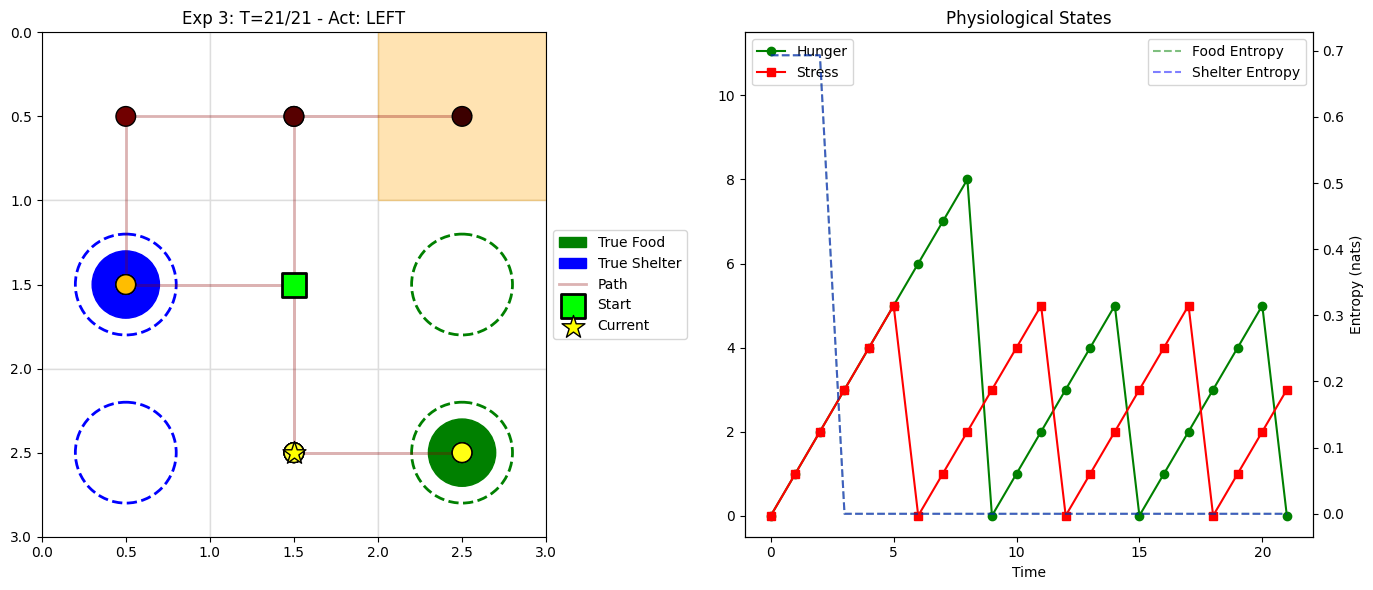

Loc: (2, 1), Hunger: 0, Stress: 3


In [59]:
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import cm

# Scenario (0 or 1 to select which candidate is real)
true_f_ctx = 1
true_s_ctx = 0

# Use Experiment 3 specific start parameters (starting_hunger, starting_stress)
obs = env.reset(start_node_3, f_ctx=true_f_ctx, s_ctx=true_s_ctx, start_hunger=starting_hunger, start_stress=starting_stress)

T3 = 21
hist_locs_3 = [env.loc]
hist_hunger_3 = [env.hunger]
hist_stress_3 = [env.stress]
# Track belief entropy about Food Context
hist_context_food = [agent.qs[3].copy()]
hist_context_shelter = [agent.qs[4].copy()]

print(f"Starting Epistemic Foraging with Drives Experiment...")

def get_entropy(dist):
    return -np.sum(dist * np.log(dist + 1e-16))

for t in range(T3):
    # Agent Action
    qs = agent.infer_states(obs)
    agent.infer_policies()
    sampled_actions = agent.sample_action()
    move_action_id = int(sampled_actions[0])
    move_action = actions[move_action_id]
    
    # Store beliefs
    hist_context_food.append(qs[3].copy())
    hist_context_shelter.append(qs[4].copy())
    
    # Step Environment
    obs = env.step(move_action)
    
    # Update History
    hist_locs_3.append(env.loc)
    hist_hunger_3.append(env.hunger)
    hist_stress_3.append(env.stress)

    # --- Live Visualization ---
    clear_output(wait=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Map
    ax_map = axes[0]
    ax_map.set_xlim(0, grid_dims[1])
    ax_map.set_ylim(grid_dims[0], 0)
    ax_map.set_aspect('equal')
    ax_map.set_title(f"Exp 3: T={t+1}/{T3} - Act: {move_action}")

    # Grid Lines
    for y in range(grid_dims[0]):
        for x in range(grid_dims[1]):
            rect = patches.Rectangle((x, y), 1, 1, linewidth=1, edgecolor='#ddd', facecolor='white')
            ax_map.add_patch(rect)

    # Draw Features
    # Cues
    ax_map.add_patch(patches.Rectangle((cue_loc[1], cue_loc[0]), 1, 1, color='orange', alpha=0.3))
    ax_map.text(cue_loc[1]+0.5, cue_loc[0]+0.5, "Cue", ha='center', va='center', fontsize=8)

    # Potential Rewards (Hollow)
    for fl in food_locs:
        ax_map.add_patch(patches.Circle((fl[1]+0.5, fl[0]+0.5), 0.3, fill=False, edgecolor='green', linewidth=2, linestyle='--'))
    for sl in shelter_locs:
        ax_map.add_patch(patches.Circle((sl[1]+0.5, sl[0]+0.5), 0.3, fill=False, edgecolor='blue', linewidth=2, linestyle='--'))

    # True Rewards (Solid) - Cheat for viz
    true_f = food_locs[true_f_ctx]
    true_s = shelter_locs[true_s_ctx]
    ax_map.add_patch(patches.Circle((true_f[1]+0.5, true_f[0]+0.5), 0.2, color='green', label='True Food'))
    ax_map.add_patch(patches.Circle((true_s[1]+0.5, true_s[0]+0.5), 0.2, color='blue', label='True Shelter'))

    # Path
    locs_arr = np.array(hist_locs_3)
    temporal_colormap = cm.hot(np.linspace(0, 0.8, len(locs_arr)))
    
    if len(locs_arr) > 1:
        ax_map.plot(locs_arr[:,1]+0.5, locs_arr[:,0]+0.5, 'darkred', linewidth=2, zorder=2, alpha=0.3, label='Path')
        
    ax_map.scatter(locs_arr[:,1]+0.5, locs_arr[:,0]+0.5, 200, c=temporal_colormap, zorder=3, edgecolors='black')

    # Start
    ax_map.scatter(locs_arr[0,1]+0.5, locs_arr[0,0]+0.5, 300, c='lime', marker='s', zorder=4, edgecolors='black', linewidth=2, label='Start')
    
    # Current
    ax_map.scatter(locs_arr[-1,1]+0.5, locs_arr[-1,0]+0.5, 300, c='yellow', marker='*', zorder=4, edgecolors='black', label='Current')
    ax_map.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    # Stats
    ax_stats = axes[1]
    ax_stats.plot(hist_hunger_3, 'g-o', label='Hunger')
    ax_stats.plot(hist_stress_3, 'r-s', label='Stress')
    ax_stats.set_title("Physiological States")
    ax_stats.set_ylim(-0.5, 11.5)
    ax_stats.set_xlabel("Time")
    ax_stats.legend(loc='upper left')

    # Entropy (Uncertainty)
    ax_ent = ax_stats.twinx()
    k_food = [get_entropy(d) for d in hist_context_food]
    k_shelter = [get_entropy(d) for d in hist_context_shelter]
    
    ax_ent.plot(k_food, 'g--', label='Food Entropy', alpha=0.5)
    ax_ent.plot(k_shelter, 'b--', label='Shelter Entropy', alpha=0.5)
    
    ax_ent.set_ylabel("Entropy (nats)")
    ax_ent.legend(loc='upper right')

    plt.tight_layout()
    display(fig)
    plt.close(fig)
    
    print(f"Loc: {env.loc}, Hunger: {env.hunger}, Stress: {env.stress}")
    if env.loc == env.cue_loc: print("  [!] Observed Cue!")
    if env.loc == food_locs[true_f_ctx]: print("  [+] Found Food!")
    if env.loc == shelter_locs[true_s_ctx]: print("  [+] Found Shelter!")